In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [18]:
image_path = '../output_images/player_1.jpg'
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

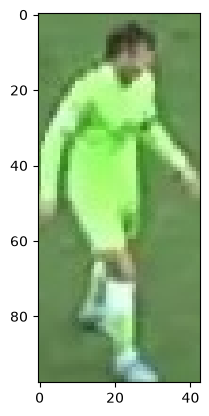

In [19]:
plt.imshow(image)
plt.show()

### Take the top half of the image

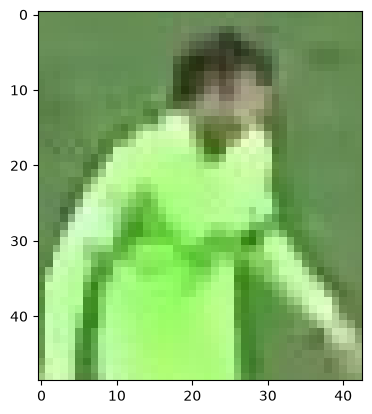

In [20]:
top_half_image = image[0: int(image.shape[0]/2), :]
plt.imshow(top_half_image)
plt.show()

### Cluster the image in two cluster

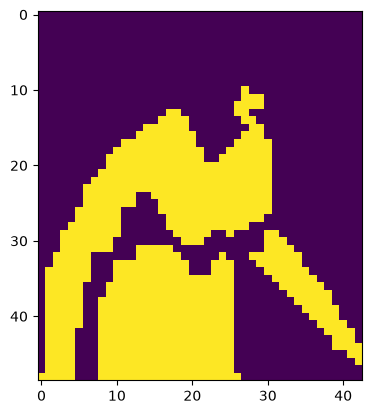

In [23]:
#Reshape the image into 2D array
reshaped_image = top_half_image.reshape(-1, 3)

#perform k-means clustering to find the dominant colors
kmeans = KMeans(n_clusters=2, random_state=0).fit(reshaped_image)

#Get the cluster centers (dominant colors)
labels = kmeans.labels_

#reshape the labels into the original image shape
clustered_image = labels.reshape(top_half_image.shape[0], top_half_image.shape[1])

#display the clustered image
plt.imshow(clustered_image, cmap='viridis')
plt.show()

In [25]:
corner_clustered_image = clustered_image[0, 0], clustered_image[-1, 0], clustered_image[0, -1], clustered_image[-1, -1]
non_player_cluster = max(set(corner_clustered_image), key=corner_clustered_image.count)
print(non_player_cluster)


0


In [26]:
player_cluster = 1-non_player_cluster
print(player_cluster)

1


In [27]:
kmeans.cluster_centers_[player_cluster]

array([176.28571429, 243.01310616, 140.49934469])